In [3]:
import pandas as pd
import random                                   
import numpy as np                             
import matplotlib.pyplot as plt                  
import tensorflow as tf                         
import tensorflow.keras as keras    
import cv2 as cv            
  
import csv                      
import numpy as np                               
import matplotlib.pyplot as plt 

from sklearn.neighbors import KNeighborsClassifier   
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  
from sklearn.preprocessing import MinMaxScaler       
from sklearn.preprocessing import StandardScaler    
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import MinMaxScaler        
from sklearn.preprocessing import StandardScaler     
from sklearn.model_selection import cross_val_score   
from sklearn.model_selection import RepeatedStratifiedKFold 
from sklearn.model_selection import RepeatedKFold    
from sklearn.model_selection import LeaveOneOut

In [4]:
def relu(x):
    return np.max([0.0,x])

def linear(x):
    return x
def conv(pic, conv_matrix, af=linear, bias=None):
    size_x_conv = conv_matrix.shape[0]
    size_y_conv = conv_matrix.shape[1]

    num_filters = conv_matrix.shape[2]
    
    len_x = pic.shape[0]-size_x_conv+1
    len_y = pic.shape[1]-size_y_conv+1

    num_lines = int(np.ceil(num_filters/10))

    fig = plt.figure(figsize=(20,num_lines*1.5))

    if bias is None:
        bias = np.zeros(num_filters)
    
    nplt = 1
    for f in range(num_filters):
        pic_conv = np.zeros((len_x,len_y))

        for i in range(len_x):
            for j in range(len_y):
                pic_conv[i,j] = af((pic[i:i+size_x_conv,j:j+size_y_conv]*conv_matrix[:,:,f]).sum()+bias[f])
            
        ax = fig.add_subplot(num_lines,10,nplt)
        ax.axis('off')
        ax.set_title(str(f))

        plt.imshow(pic_conv)
        nplt += 1
    return

def plot_samples(xdata, ydata, amount=40):
    for number in range(10):
        indeces = np.random.choice(np.where(ydata == number)[0],size=amount,replace=False)
        fig = plt.figure(figsize=(20,6))
        fig.suptitle("examples for number "+str(number)+":")
        nplt = 1
        for index in indeces:
            ax = fig.add_subplot(4,10,nplt)
            ax.axis('off')
            plt.imshow(xdata[index])
            nplt += 1


def rotate_image(image, rotation_angle=0, scale=1):
    height, width = image.shape
    M = cv.getRotationMatrix2D(((width - 1) / 2.0, (height - 1) / 2.0),
                               rotation_angle, scale)
    image_rotated = cv.warpAffine(np.squeeze(image), M, (width, height))

    return image_rotated
def add_noise(img, sigma=0.1):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0, 1)


In [5]:
### load dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


### normalizing the data
x_train = x_train / 255
x_test = x_test / 255
##add rotation + noise 

x_aug = []
y_aug = []

for img, label in zip(x_train, y_train):
    x_aug.append(img)
    y_aug.append(label)
    x_aug.append(rotate_image(img, 10))
    y_aug.append(label)
    x_aug.append(add_noise(img, sigma=0.1))
    y_aug.append(label)

x_aug = np.array(x_aug)          

#flatting 

x_train_flat = x_aug.reshape(len(x_aug), -1)
x_test_flat = x_test.reshape(len(x_test), -1)


### plotting some examples for each number
#plot_samples(x_train, y_train)

1 - Logistische Regression 

In [6]:
from sklearn.linear_model import LogisticRegression  
from sklearn.model_selection import GridSearchCV


In [7]:
lr = LogisticRegression(tol=0.01,penalty=None)

In [8]:

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train_flat, y_aug)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8535277777777779


In [9]:
best_model = grid.best_estimator_
test_acc = best_model.score(x_test_flat, y_test)

print("Test accuracy:", test_acc)

Test accuracy: 0.851


#Training of our data set without Rotation and noise

In [10]:
### load dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


### normalizing the data
x_train = x_train / 255
x_test = x_test / 255
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)


In [11]:
lR = LogisticRegression(max_iter = 500 , random_state=42 )

In [12]:
lR.fit(x_train_flat,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [13]:
y_val_pred = lR.predict(x_test_flat)

In [14]:

acc = accuracy_score(y_test, y_val_pred)
acc 

0.9264

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


# Pipeline : PCA → Logistic Regression
pipe_pca = Pipeline([
    ('pca', PCA(n_components=100, whiten=True, random_state=42)),
    ('lr',  LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=42))
])

pipe_pca.fit(x_train_flat, y_train)
y_pred_pca = pipe_pca.predict(x_test_flat)

print("Accuracy with PCA (100 components) :", accuracy_score(y_test, y_pred_pca))

Accuracy avec PCA (100 composantes) : 0.9221


In [20]:
#Comparing depending of the number of components of PCA
results = {}
for n in [50, 100, 150, 200,300]:
    p = Pipeline([
        ('pca', PCA(n_components=n, whiten=True, random_state=42)),
        ('lr',  LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=42))
    ])
    p.fit(x_train_flat, y_train)
    acc = accuracy_score(y_test, p.predict(x_test_flat))
    results[n] = acc
    print(f"n_components={n:4d}  →  accuracy={acc:.4f}")

best_n = max(results, key=results.get)
print(f"\nbest n_components : {best_n}  ({results[best_n]:.4f})")

n_components=  50  →  accuracy=0.9118
n_components= 100  →  accuracy=0.9221
n_components= 150  →  accuracy=0.9236
n_components= 200  →  accuracy=0.9264
n_components= 300  →  accuracy=0.9241

best n_components : 200  (0.9264)


In [18]:


param_grid = {
    "C":       [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver":  ["saga"]   # saga supporte l1 ET l2
}

lr_grid = LogisticRegression(max_iter=1000, random_state=42)

grid = GridSearchCV(
    lr_grid,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train_flat, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleure accuracy CV:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Meilleurs paramètres : {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Meilleure accuracy CV: 0.9211833333333332


In [19]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(x_test_flat)

print("Test accuracy (best GridSearch):", accuracy_score(y_test, y_pred_best))

# Résume of results per combinaison

cv_results = pd.DataFrame(grid.cv_results_)
cols = ['param_C', 'param_penalty', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(cv_results[cols].sort_values('rank_test_score').to_string(index=False))

Test accuracy (best GridSearch): 0.9258
 param_C param_penalty  mean_test_score  std_test_score  rank_test_score
   0.100            l2         0.921183        0.004062                1
   1.000            l1         0.920417        0.004514                2
   1.000            l2         0.919383        0.004806                3
   0.100            l1         0.914850        0.004570                4
  10.000            l1         0.914600        0.005671                5
  10.000            l2         0.914583        0.005349                6
   0.010            l2         0.912133        0.004694                7
   0.001            l2         0.889083        0.006057                8
   0.010            l1         0.878250        0.007461                9
   0.001            l1         0.699267        0.010301               10


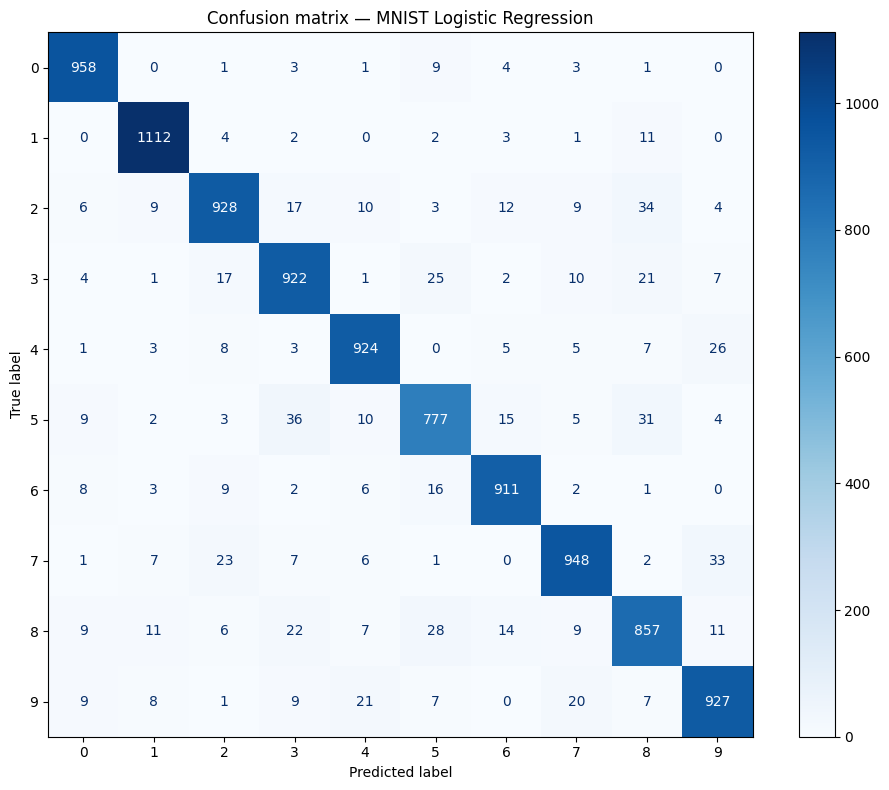


Classification report :
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.94      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
#Using the forecasts of our best model(here lR or best_model)
y_pred = lR.predict(x_test_flat)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=list(range(10)),
    cmap='Blues',
    ax=ax
)
ax.set_title("Confusion matrix — MNIST Logistic Regression")
plt.tight_layout()
plt.show()

print("\nClassification report :")
print(classification_report(y_test, y_pred))

Number of errors : 736 / 10000


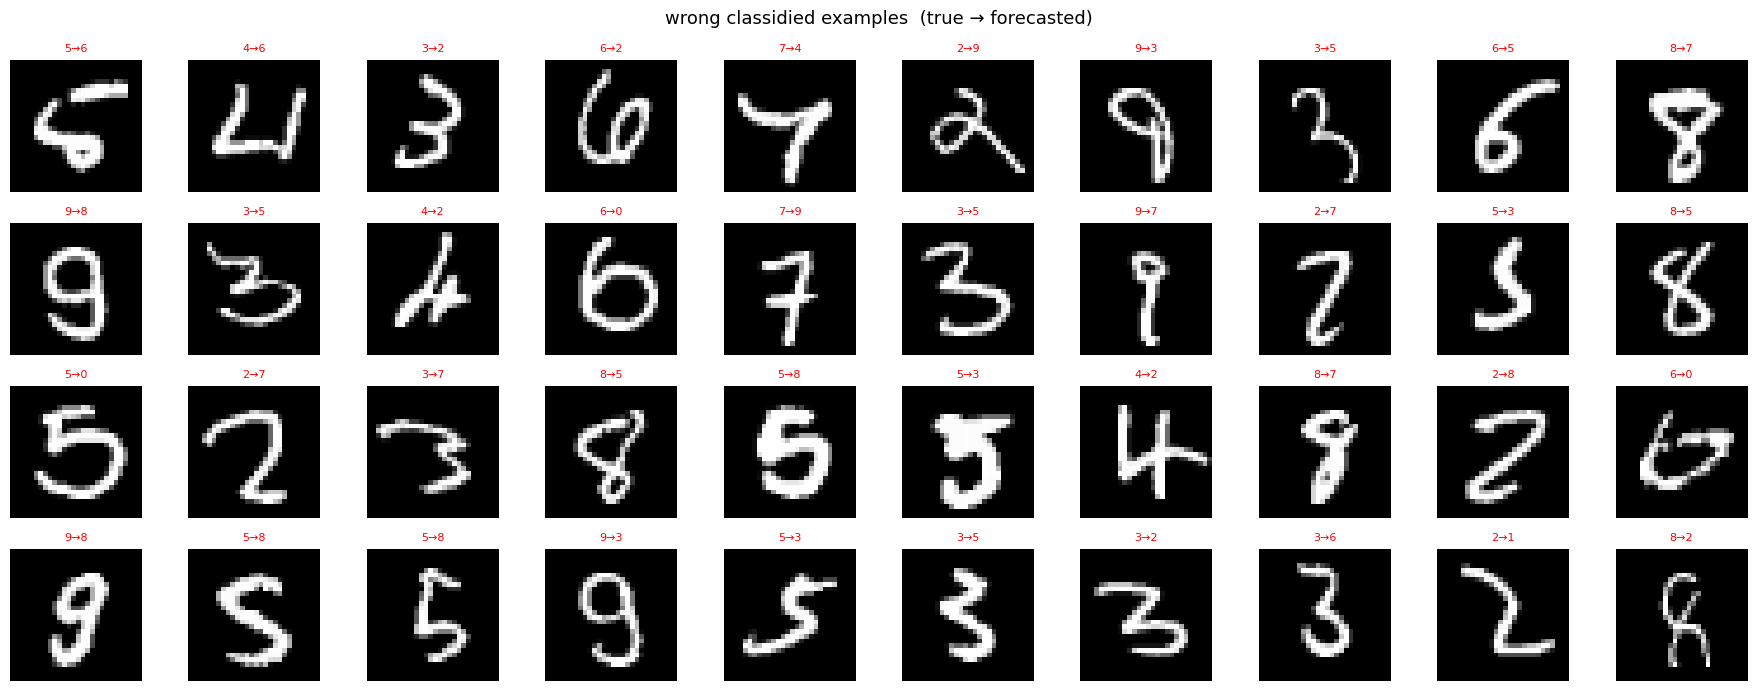

In [23]:
# Indices of wrong classidied examples
errors = np.where(y_pred != y_test)[0]
print(f"Number of errors : {len(errors)} / {len(y_test)}")

# Display the 40 first errors 
fig, axes = plt.subplots(4, 10, figsize=(18, 7))
fig.suptitle("wrong classidied examples  (true → forecasted)", fontsize=13)

for i, ax in enumerate(axes.flat):
    if i >= len(errors):
        ax.axis('off'); continue
    idx = errors[i]
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f"{y_test[idx]}→{y_pred[idx]}", fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

[learning_curve] Training set sizes: [ 4800 10971 17142 23314 29485 35657 41828 48000]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:  5.4min finished


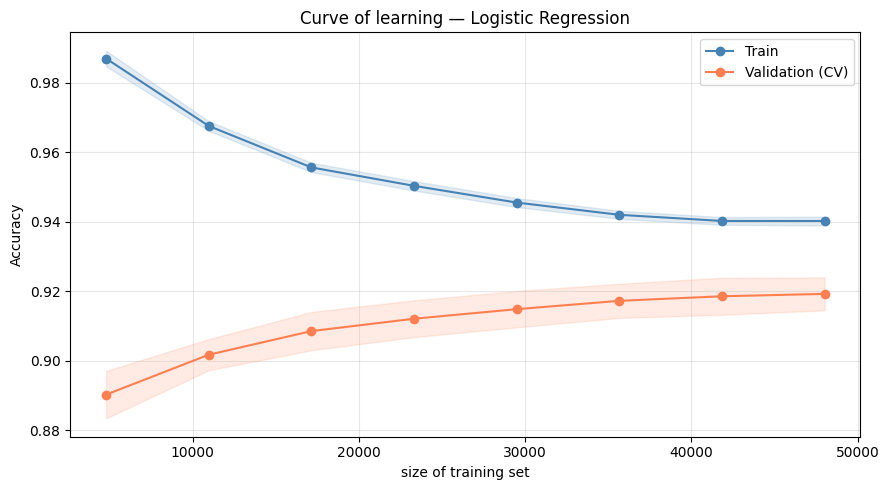

In [25]:
from sklearn.model_selection import learning_curve
# Curve of learning
train_sizes, train_scores, val_scores = learning_curve(
    lR,
    x_train_flat, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Validation (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')

plt.xlabel("size of training set")
plt.ylabel("Accuracy")
plt.title("Curve of learning — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# If train ≈ val → underfitting (bias). If train >> val → overfitting (variance).
# On MNIST + LR you typically see bias — a more complex model would help.

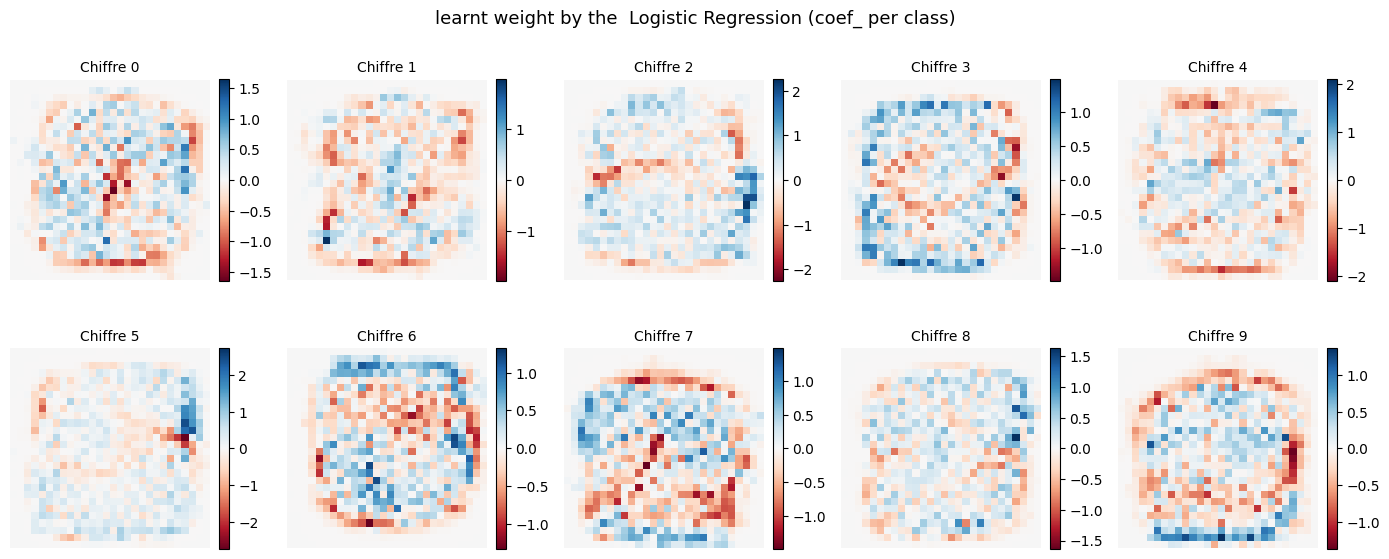

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("learnt weight by the  Logistic Regression (coef_ per class)", fontsize=13)

for digit, ax in enumerate(axes.flat):
    weights = lR.coef_[digit].reshape(28, 28)
    vmax = np.abs(weights).max()
    im = ax.imshow(weights, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f"Chiffre {digit}", fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

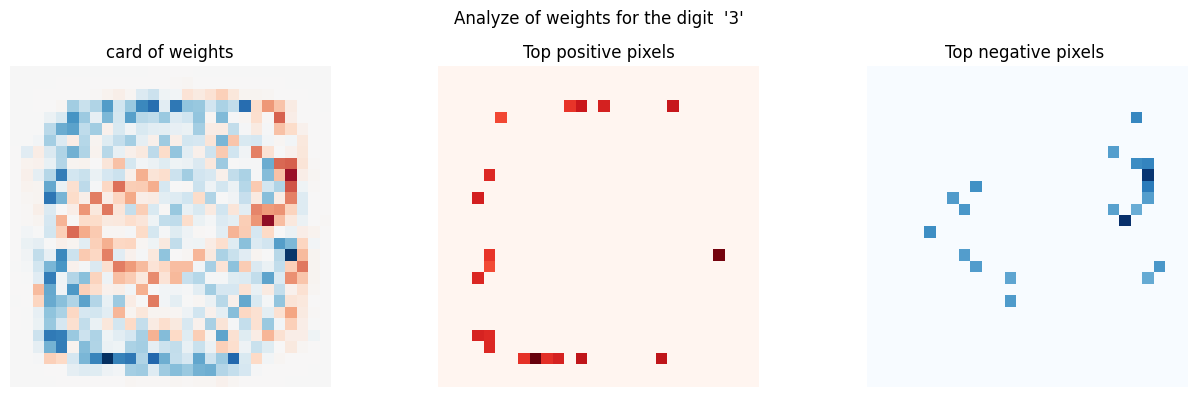

In [28]:

digit = 3  #change this digit to inspect another one

weights = lR.coef_[digit].reshape(28, 28)
flat_w  = lR.coef_[digit]

# Top 20 positive (red) and negative (blue) pixels
top_pos = np.argsort(flat_w)[-20:]
top_neg = np.argsort(flat_w)[:20]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"Analyze of weights for the digit  '{digit}'", fontsize=12)

# Heatmap of weights
vmax = np.abs(weights).max()
axes[0].imshow(weights, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[0].set_title("card of weights"); axes[0].axis('off')

# Positive Pixel 
mask_pos = np.zeros(784); mask_pos[top_pos] = flat_w[top_pos]
axes[1].imshow(mask_pos.reshape(28,28), cmap='Reds')
axes[1].set_title("Top positive pixels"); axes[1].axis('off')

#Negative Pixels 
mask_neg = np.zeros(784); mask_neg[top_neg] = np.abs(flat_w[top_neg])
axes[2].imshow(mask_neg.reshape(28,28), cmap='Blues')
axes[2].set_title("Top negative pixels "); axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Red = pixels pushing toward this digit. Blue = pixels pushing toward other classes.
# This is the main advantage of LR over neural networks: it is fully interpretable.